# Readout Integration Weights

This notebook demonstrates a simplified readout-processing workflow for **one resonator**.

We denote the raw ADC quadratures by $I^{\mathrm{raw}}[n]$ and $Q^{\mathrm{raw}}[n]$, sampled at **1 GHz**. Each record spans
$0 \leq t_n < 16\,\mu\mathrm{s}$ with indices $0 \leq n \leq 15999$.

Because the qubit can decay during readout, the signal contrast is typically strongest early in the record. The integration workflow therefore uses time-dependent weights that emphasize early samples.

## Inputs
- `data/res_1_IJK_sample.hdf5`
- `data/integration_weights.hdf5`
- `data/ADC_sample.hdf5` (produced by `notebooks/A01_*`)

## Outputs
- `si_figures/integration_weights_windows.{png,pdf}`
- `si_figures/integration_weights.{png,pdf}`

## Pipeline (simplified)
1. Coarse-grain the raw record into **24 rectangular windows** $w^{\mathrm{rect}}_j[n]$.
2. Build **48 window features**: 24 for I and 24 for Q.
3. Run LDA to obtain four integration modes $I, J, K, L$.
   - $I$: first LDA axis
   - $J$: 90-degree rotation of $I$
   - Project data orthogonally to remove $I, J$
   - $K$: second LDA axis on the residual
   - $L$: 90-degree rotation of $K$

```mermaid
flowchart LR
  adc["Raw ADC I/Q<br/>1 GHz, 16 us record"] --> rect["24 rectangular windows<br/>48 coarse-grained features"]
  rect --> lda1["LDA #1 -> mode I<br/>90-degree rotation -> mode J"]
  lda1 --> proj["Project out I and J"]
  proj --> lda2["LDA #2 -> mode K<br/>90-degree rotation -> mode L"]
  lda2 --> fig["Plot/export windows and I,J,K,L weights"]
```


In [1]:
import os
from pathlib import Path

# Ensure relative paths work regardless of where the notebook is launched from.
_repo_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "data").exists():
        _repo_root = p
        break
if _repo_root is not None:
    os.chdir(_repo_root)
print("Working directory:", Path.cwd())

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import h5py
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Working directory: /Users/chellymac/projects/positronium-sensing


## Windowed features and mode definitions

The 24 window bank is denser at early times (shorter windows) and coarser later (longer windows), so transient pre-decay dynamics are represented with higher time resolution.

For each window $j$,

$$
\begin{aligned}
I^{\mathrm{rect}}_j &= \sum_n w^{\mathrm{rect}}_j[n]\left(I^{\mathrm{raw}}[n]\cos(\omega_{IF} t_n + \phi_F) + Q^{\mathrm{raw}}[n]\sin(\omega_{IF} t_n + \phi_F)\right), \\
Q^{\mathrm{rect}}_j &= \sum_n w^{\mathrm{rect}}_j[n]\left(-I^{\mathrm{raw}}[n]\sin(\omega_{IF} t_n + \phi_F) + Q^{\mathrm{raw}}[n]\cos(\omega_{IF} t_n + \phi_F)\right).
\end{aligned}
$$

These $\{I^{\mathrm{rect}}_j, Q^{\mathrm{rect}}_j\}_{j=0}^{23}$ values form a 48-dimensional feature vector used by LDA.

The learned integration modes are reported as cosine/sine weights for $I, J, K, L$. In this demo they are piecewise-constant over the same 24 windows:

$$
M \in \{I,J,K,L\}:\quad
M = \sum_n w^{M}_{\mathrm{cos}}[n]\,I^{\mathrm{raw}}[n]\cos(\omega_{IF} t_n + \phi_F)
    + w^{M}_{\mathrm{sin}}[n]\,Q^{\mathrm{raw}}[n]\sin(\omega_{IF} t_n + \phi_F).
$$

Including rotated quadratures ($J$ and $L$) helps robustness to phase shifts and is useful when optimizing readout frequency and amplifier settings.


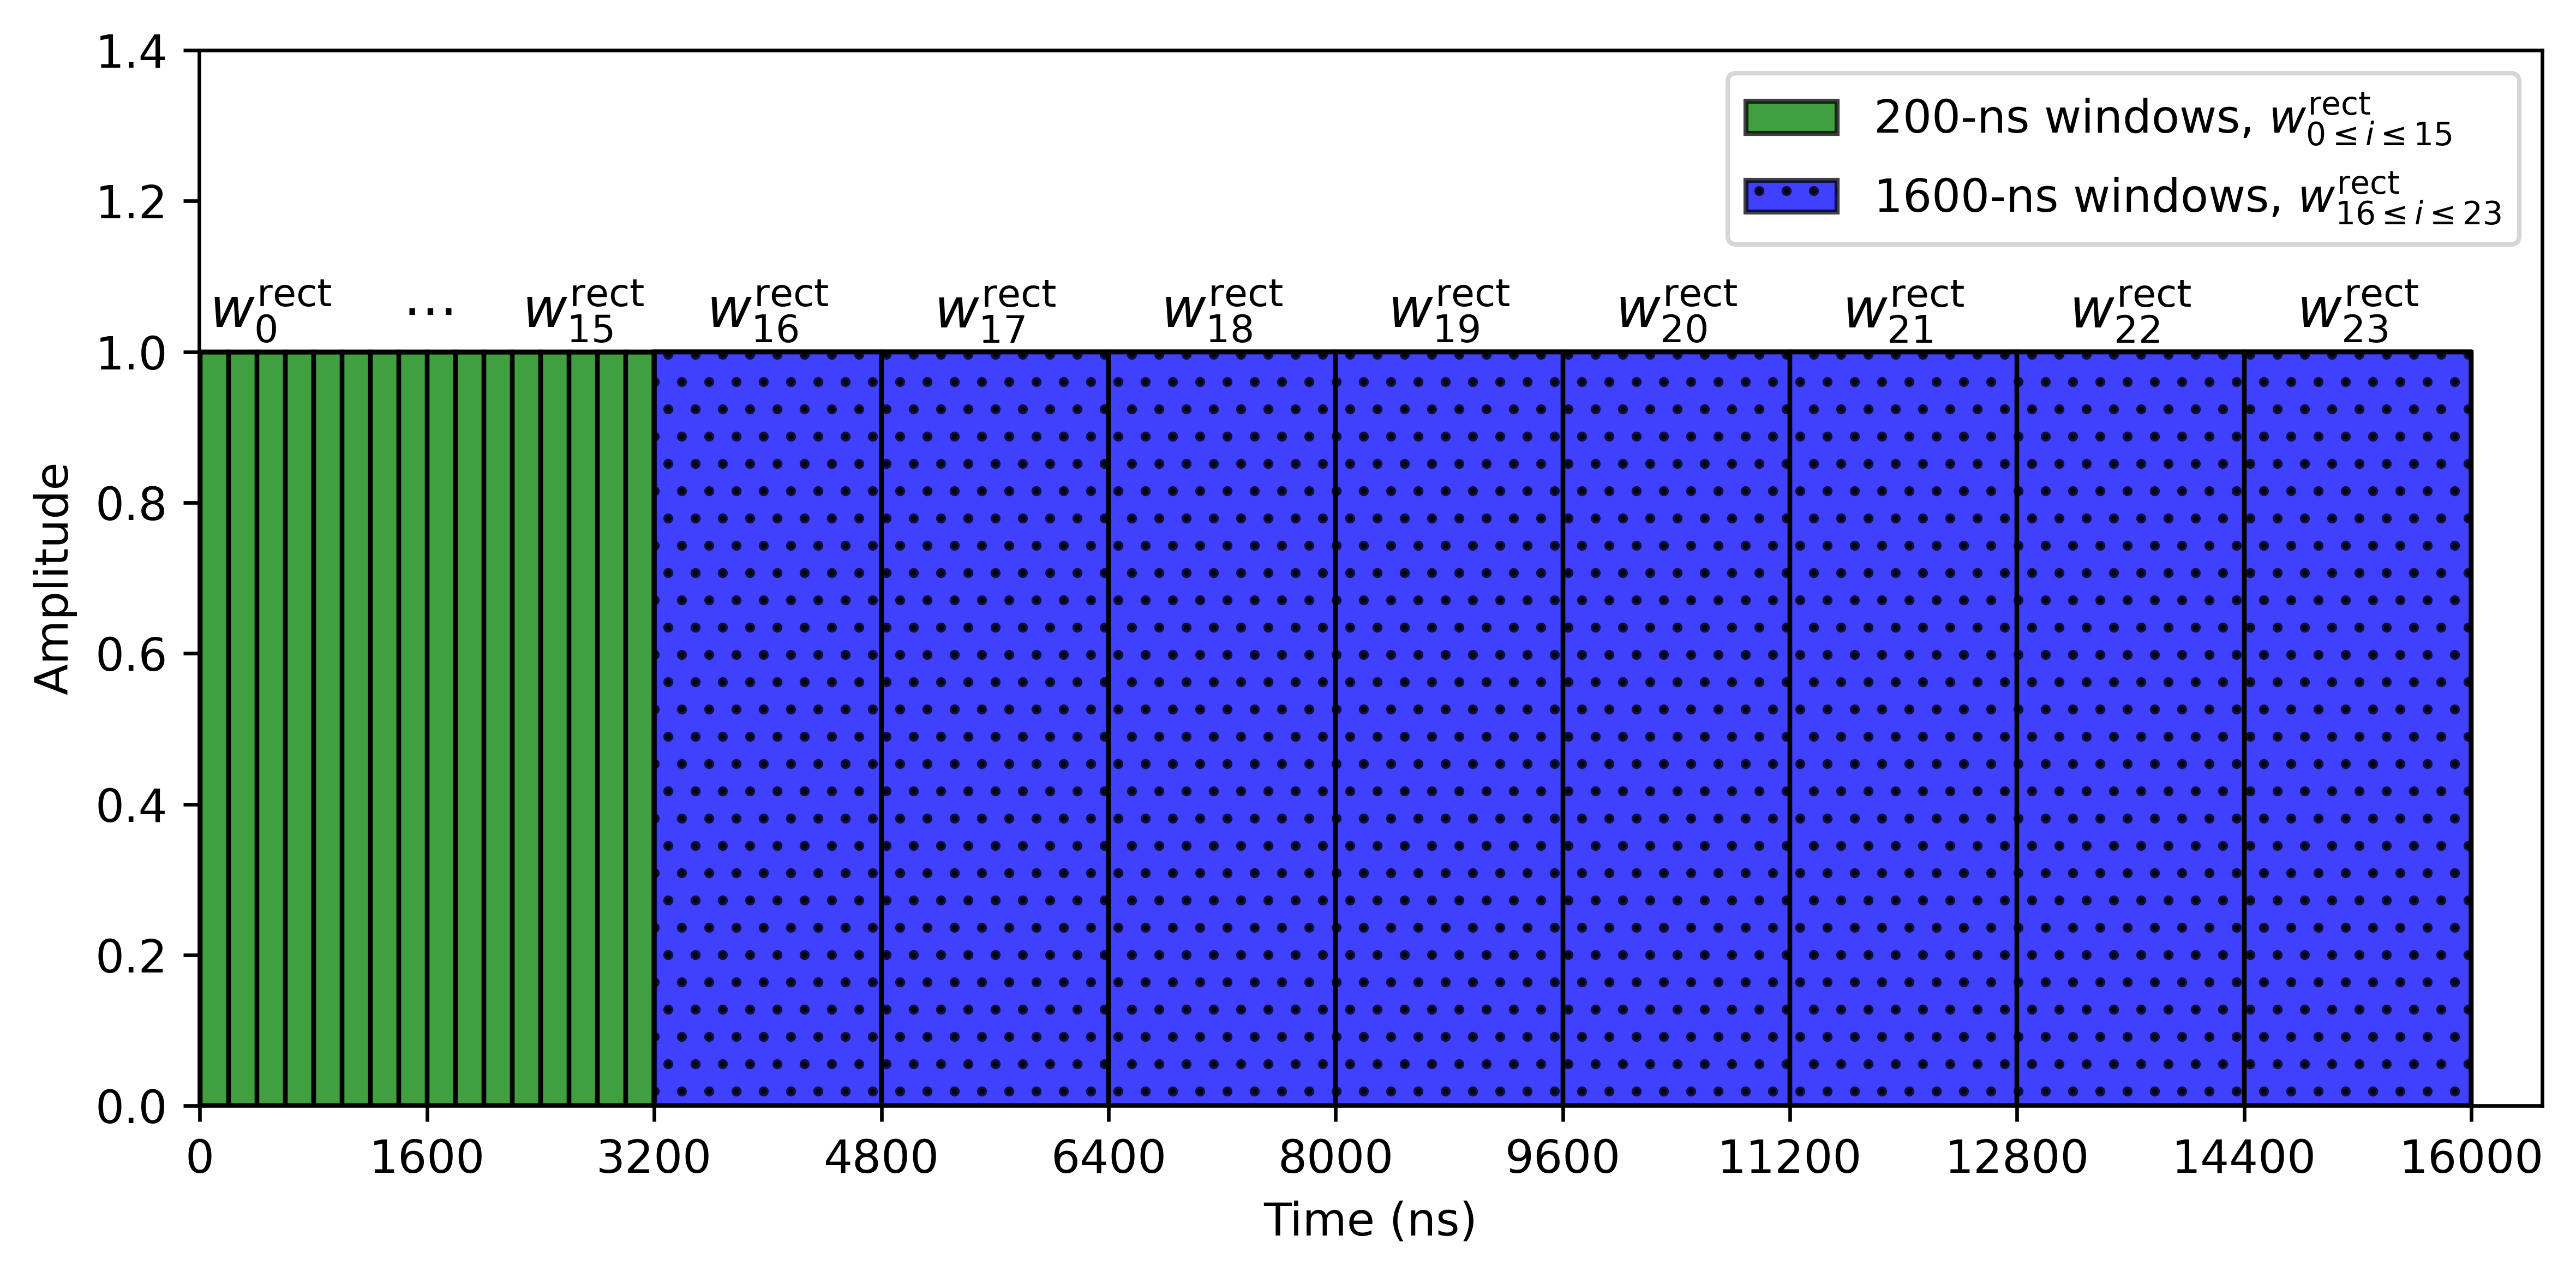

In [2]:
# One readout record: 16 microseconds sampled at 1 GHz -> 16000 time points.
integration_len_ns = 16000

t_ns = np.arange(integration_len_ns)
window_blank = np.zeros(integration_len_ns, dtype=np.float64)

purple = '#6700CC'
orange = '#FFAA00'
gray = '#777777'

fig, ax = plt.subplots(figsize=(8, 4), dpi=600)

# First 16 windows are narrow (200 ns) to capture early-time transients.
windows_200ns = window_blank.copy()
windows_200ns[:3200] = 1.0
ax.fill_between(t_ns, windows_200ns, color='g', label=r'200-ns windows, $w^{\mathrm{rect}}_{0\leq i \leq 15}$', alpha=0.75, edgecolor='k', linewidth=1.1)

# Final 8 windows are wider (1600 ns) after the highest-SNR transient region.
windows_1600ns = window_blank.copy()
windows_1600ns[3200:] = 1.0
ax.fill_between(t_ns, windows_1600ns, color='b', label=r'1600-ns windows, $w^{\mathrm{rect}}_{16\leq i \leq 23}$', alpha=0.75, edgecolor='k', linewidth=1.1, hatch='..')

y_labels = 1.032

# Draw the 24 rectangular windows explicitly.
for i in range(16):
    rect = patches.Rectangle((i*200, 0.0), 200, 1, linewidth=1, edgecolor='k', fill=False)
    ax.add_patch(rect)

for i in range(2, 10):
    rect = patches.Rectangle((i*1600, 0.0), 1600, 1, linewidth=1, edgecolor='k', fill=False)
    ax.add_patch(rect)
    ax.text(i*1600 + 800, y_labels, r'$w^{\mathrm{rect}}_{' + str(i + 14) + r'}$', ha='center', fontsize=12)

ax.text(500, y_labels, r'$w^{\mathrm{rect}}_{0}$', ha='center', fontsize=12)
ax.text(1600, y_labels, r'$\cdots$', ha='center', fontsize=12)
ax.text(2700, y_labels, r'$w^{\mathrm{rect}}_{15}$', ha='center', fontsize=12)

ax.legend()
plt.xticks(np.arange(0, 16001, 1600))
plt.xlim(-4, 16500)
plt.ylim(0, 1.4)
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
fig.tight_layout()
plt.show()


In [3]:
import os

os.makedirs("./si_figures", exist_ok=True)
fig.savefig(r"./si_figures/integration_weights_windows.png")
fig.savefig(r"./si_figures/integration_weights_windows.pdf")

In [4]:
def calc_weights(IData, QData):
    """Learn four integration modes (I, J, K, L) from windowed I/Q features.

    Parameters
    ----------
    IData, QData : np.ndarray, shape (n_shots, 2, 24)
        Window-integrated I/Q features for two classes.

    Returns
    -------
    weights_I, weights_Q : np.ndarray, shape (4, 24)
        Piecewise-constant cosine/sine weights for the four modes.
    """
    n_shots = IData.shape[0]
    n_windows = IData.shape[-1]

    # Flatten to one design matrix with both quadratures concatenated.
    # Shape: (2*n_shots, 2*n_windows)
    X = np.concatenate([IData, QData], axis=2).reshape((2 * n_shots, -1))

    # Binary labels for the two classes in the stacked dataset.
    y = np.empty((n_shots, 2), dtype=np.int32)
    y[:, 0] = 0
    y[:, 1] = 1
    y = y.flatten()

    clf = LinearDiscriminantAnalysis()

    # First discriminant axis: mode I.
    clf.fit(X, y)
    weights_IA = clf.coef_[0]
    weights_IA /= np.linalg.norm(weights_IA)

    # 90-degree rotation of I gives its quadrature partner J.
    weights_IQA = weights_IA.reshape((2, -1))
    weights_IB = np.hstack([-weights_IQA[1], weights_IQA[0]]).flatten()

    # Remove I and J components before learning the next independent axis.
    X -= np.einsum('ij,j,k->ik', X, weights_IA, weights_IA)
    X -= np.einsum('ij,j,k->ik', X, weights_IB, weights_IB)

    # Second discriminant axis on the residual: mode K.
    clf.fit(X, y)
    weights_IC = clf.coef_[0]
    weights_IC /= np.linalg.norm(weights_IC)

    # 90-degree rotation of K gives mode L.
    weights_IQC = weights_IC.reshape((2, -1))
    weights_ID = np.hstack([-weights_IQC[1], weights_IQC[0]]).flatten()

    # Stack [I, J, K, L], then convert back to (mode, quadrature, window).
    weights = np.stack([weights_IA, weights_IB, weights_IC, weights_ID], axis=0)
    weights *= np.sqrt(2 * n_windows)
    weights = weights.reshape(4, 2, -1)
    weights_I = weights[:, 0, :]
    weights_Q = weights[:, 1, :]

    return weights_I, weights_Q

durations = np.array([
    200,  200,  200,  200,  200,  200,  200,  200,  200,  200,  200,  200,
    200,  200,  200,  200, 1600, 1600, 1600, 1600, 1600, 1600, 1600, 1600
], dtype=np.int32)

def plot_weights(weights_I, weights_Q):
    # Convert window durations into step-plot boundaries in ns.
    t = 0
    t_list = [0]
    for duration in durations:
        t += duration
        t_list.append(t)

    t_list_complete = np.repeat(t_list, 2)[1: -1]
    
    n = 1
    fig = plt.figure(figsize=(7, 5), dpi=600)
    plt.subplots_adjust(left=0.08, right=0.98, bottom=0.1, top=0.98, wspace=0.25, hspace=0.25)
    ylabels = [r'$w^I$ (a.u.)', r'$w^J$ (a.u.)', r'$w^K$ (a.u.)', r'$w^L$ (a.u.)']
    cos_labels = [r'$w^I_{\mathrm{cos}}$', r'$w^J_{\mathrm{cos}}$', r'$w^K_{\mathrm{cos}}$', r'$w^L_{\mathrm{cos}}$']
    sin_labels = [r'$w^I_{\mathrm{sin}}$', r'$w^J_{\mathrm{sin}}$', r'$w^K_{\mathrm{sin}}$', r'$w^L_{\mathrm{sin}}$']
    for weights_I_n, weights_Q_n, ylabel, cos_label, sin_label in zip(weights_I, weights_Q, ylabels, cos_labels, sin_labels):
        plt.subplot(2, len(weights_I) // 2, n)
        weights_I_n_complete = np.repeat(weights_I_n, 2)
        weights_Q_n_complete = np.repeat(weights_Q_n, 2)
        plt.plot(t_list_complete, weights_I_n_complete, linestyle=(0, (2, 0.5)), label=cos_label, color='purple')
        plt.plot(t_list_complete, weights_Q_n_complete, linestyle='-', label=sin_label, color='orange')
        plt.xticks(np.arange(0, 16001, 3200))
        plt.legend()
        plt.xlabel('Time (ns)')
        plt.ylabel(ylabel)
        n += 1
    plt.tight_layout
    plt.show()
    return fig


In [5]:
ADC_sample_file = r'./data/ADC_sample.hdf5'
with h5py.File(ADC_sample_file, 'r') as hf:
    IData_sample = np.array(hf['IData_sample'][:])
    QData_sample = np.array(hf['QData_sample'][:])

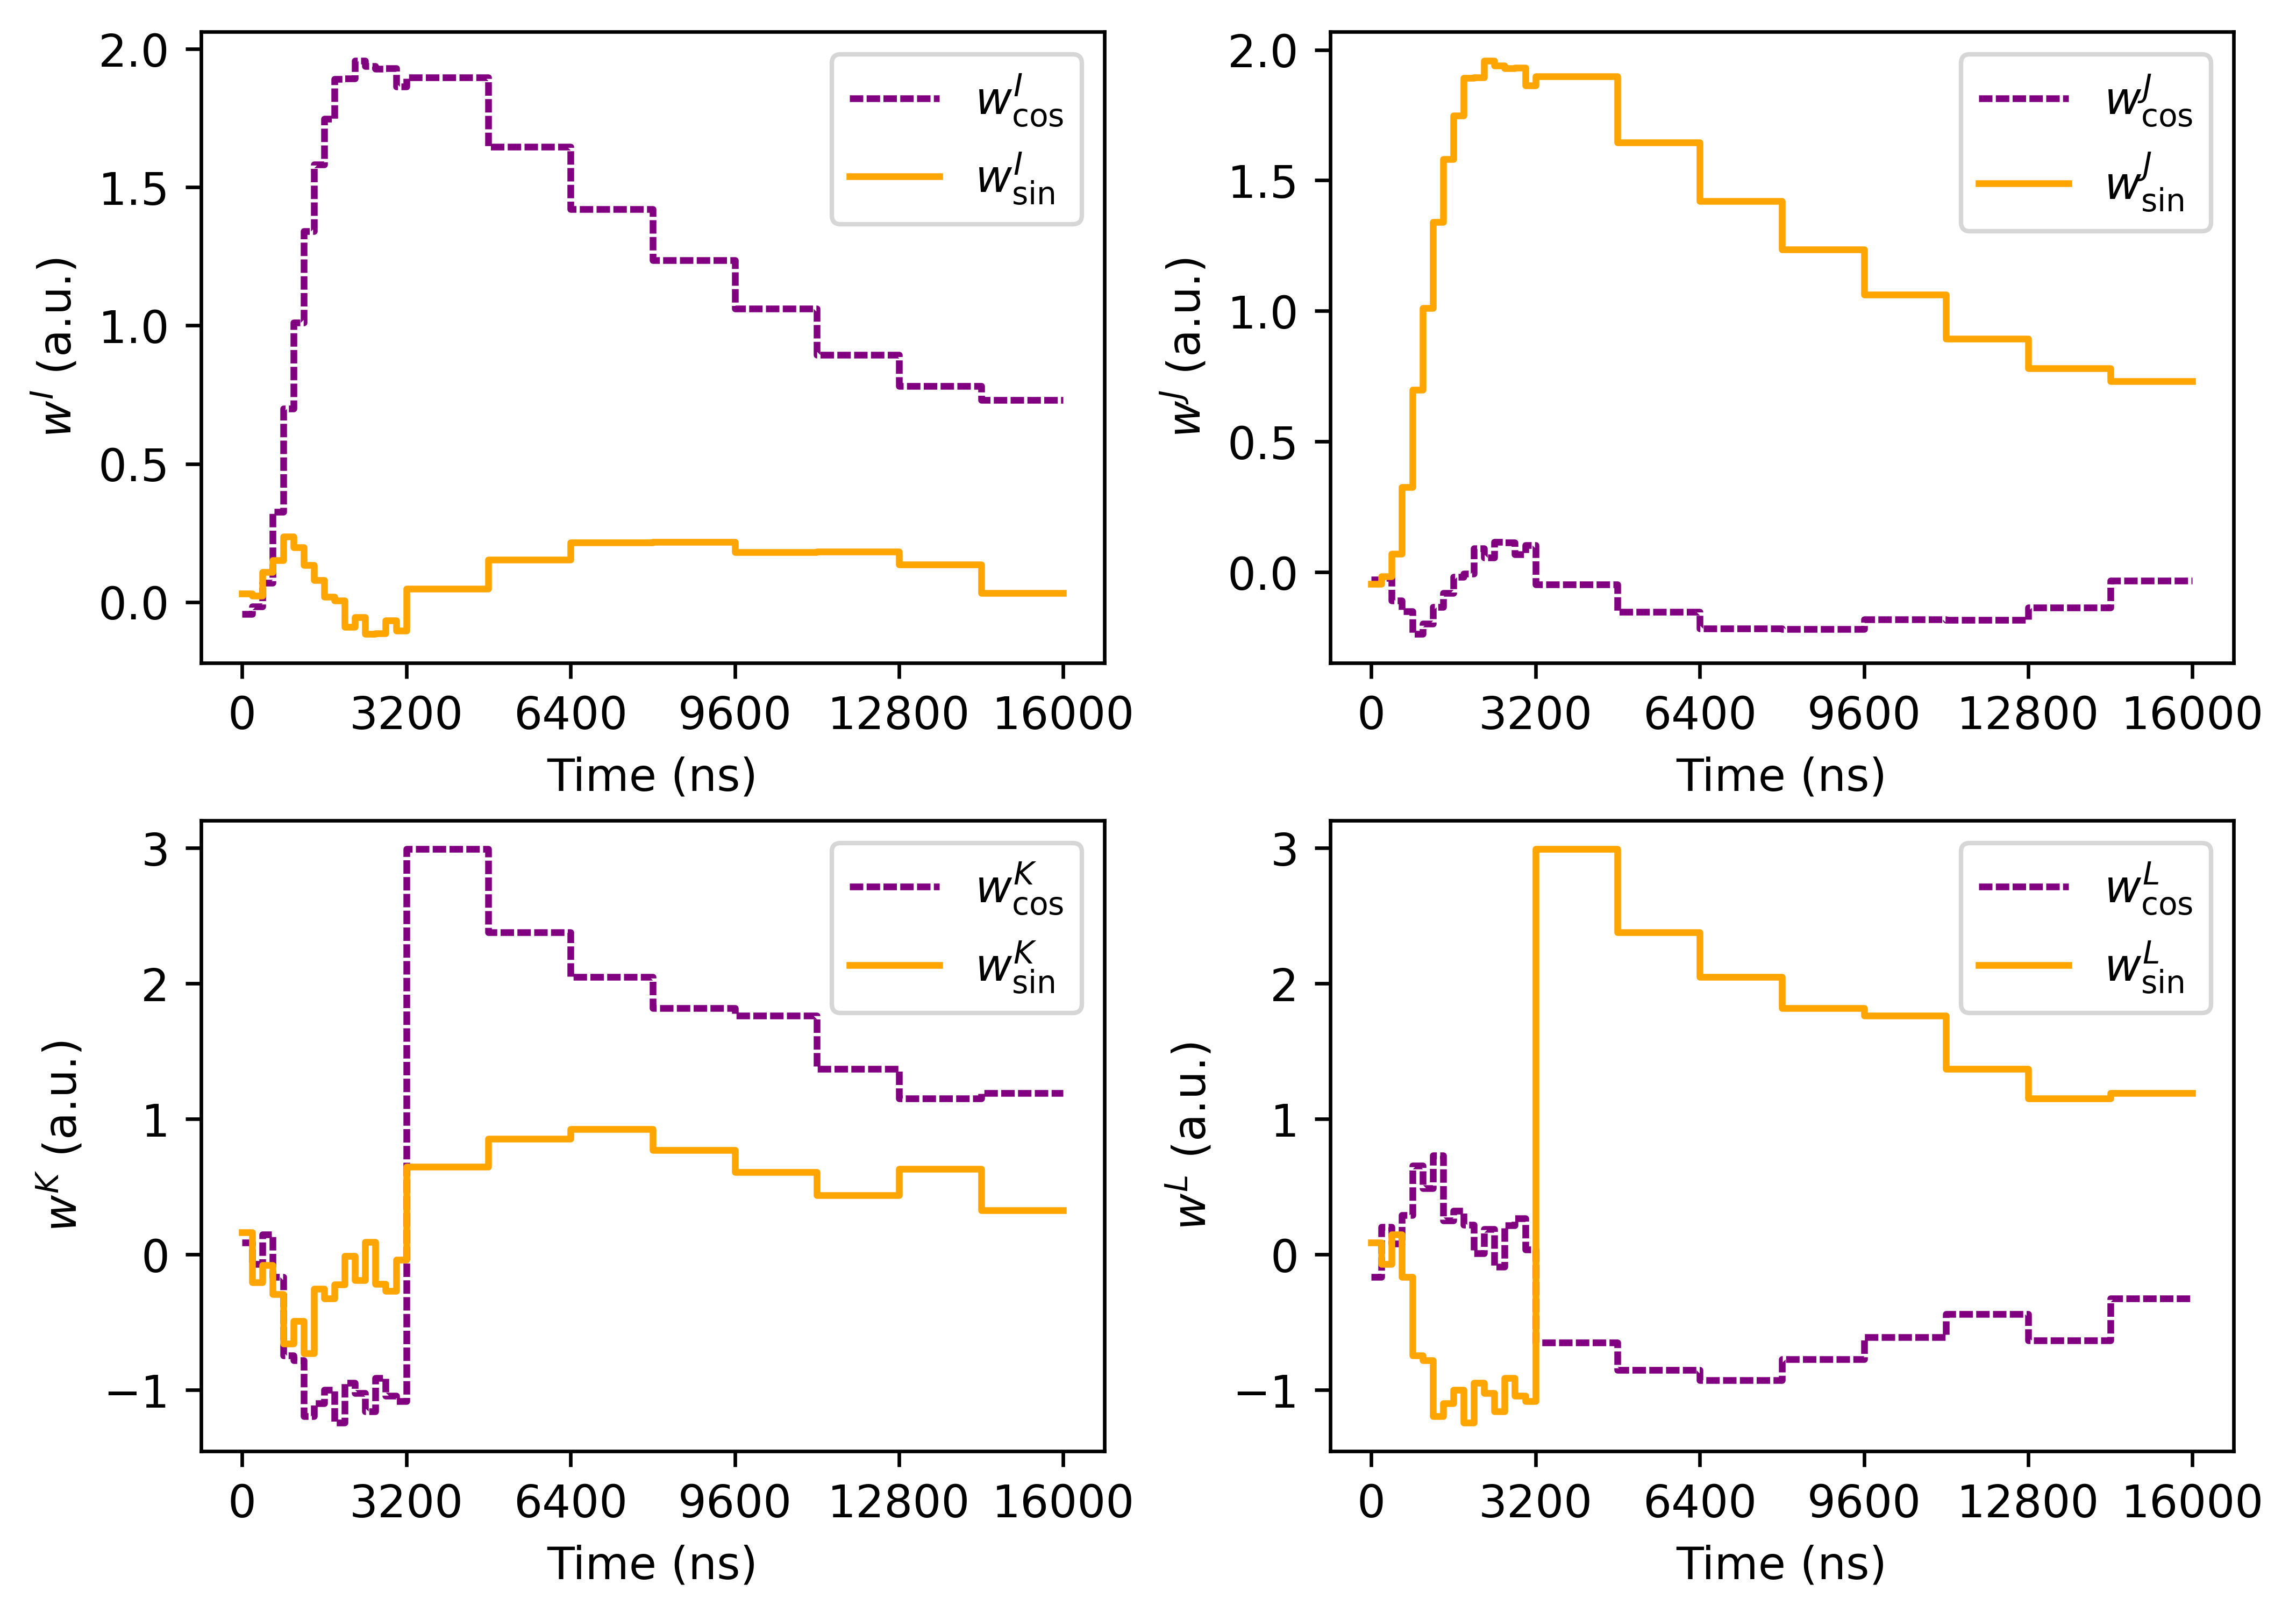

In [6]:
res_1_iw_I_new, res_1_iw_Q_new = calc_weights(IData_sample, QData_sample)
fig = plot_weights(res_1_iw_I_new, res_1_iw_Q_new)

In [7]:
import os

os.makedirs("./si_figures", exist_ok=True)
fig.savefig(r"./si_figures/integration_weights.png")
fig.savefig(r"./si_figures/integration_weights.pdf")